In [1]:
from learn_to_infer import Worker
from task import probabilistic_task
import pandas as pd
import torch
import numpy as np
from matplotlib import pyplot as plt

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

import numpy as np

In [2]:
nb_simuls = 5000

# performances as a function of the sequence length
nb_agents = 30
false_positive_rate_function_of_trials = np.zeros((nb_agents, nb_simuls, 200))
emission_function_of_trials = np.zeros([nb_agents, nb_simuls, 10, 201])
performances = np.zeros([8, nb_agents])
performances_w_emission = np.zeros([nb_agents])
performances_w_emissiontrained = np.zeros([nb_agents])

for idx_agent in range(nb_agents):
    for train_w_emission in [True, False]:
        self = Worker(
            probabilistic_task(),
            "results/source/saved_models",
            "WP_GRU_agent{0}".format(idx_agent),
            w_emission=True,
            train_w_emission=train_w_emission,
            train_in_cat_task_from_scratch=False,
            entropy_reg=None,
            associationFinetunedOnly=False,
        )

        self.load_model(nb_episodes=50000) #nb_episodes=50000) #if not train_w_emission and (idx_agent + 1) != 18 else self.load_model(nb_episodes=40000)        

        # 3 steps
        self.env.probas = None
        np.random.seed(1)
        self.env.generate_test_task(num_tasks=nb_simuls, num_trials=200, num_steps=5, probas=None)
        
        if not train_w_emission:
            result0_1 = self.evaluate(use_probabilitistic_reward=False)
            performances_w_emission[idx_agent] = (result0_1['logpredicts'].argmax(-1).detach() == self.env.correct_weather).float().mean()
        else:
            result2 = self.evaluate()
            performances_w_emissiontrained[idx_agent] = (result2['logpredicts'].argmax(-1).detach() == self.env.correct_weather).float().mean()

    for i_reg, entropy_reg in enumerate([0, 0.1, 0.4, 0.7, 1, 2, 4, 8]):
        self = Worker(
            probabilistic_task(),
            "results/source/saved_models",
            "WP_GRU_agent{0}".format(idx_agent),
            w_emission=True,
            train_w_emission=True,
            train_in_cat_task_from_scratch=True,
            entropy_reg=entropy_reg
        )

        self.load_model()
        np.random.seed(1)
        self.env.generate_test_task(num_tasks=nb_simuls, num_trials=200, num_steps=5, probas=None)
        result = self.evaluate()    
        performances[i_reg, idx_agent] = (result['logpredicts'].argmax(-1).detach() == self.env.correct_weather).float().mean()

loaded the emission model with 50000 iterations
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
key gru_emission.weight_ih_l0 not found in state_dict
key gru_emission.weight_hh_l0 not found in state_dict
key gru_emission.bias_ih_l0 not found in state_dict
key gru_emission.bias_hh_l0 not found in state_dict
loaded the association model
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_True_trainInCatTaskFromScratch_False/model-50000.pth
loaded W_output_association
loaded W_output_emission
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gr

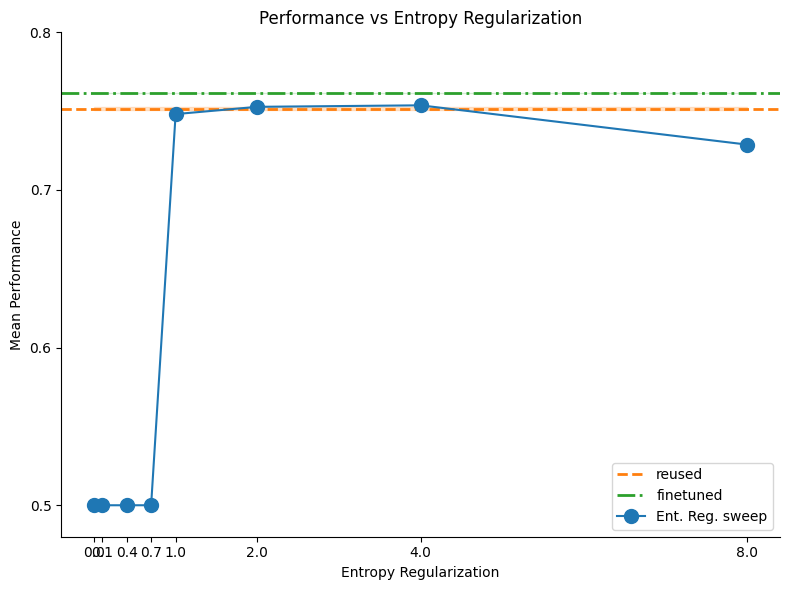

In [3]:
import matplotlib.pyplot as plt

mean_perf = performances.mean(axis=1)
sem_perf = performances.std(axis=1) / np.sqrt(nb_simuls)

# For horizontal lines and error shading
mean_w_emission = performances_w_emission.mean()
sem_w_emission = performances_w_emission.std() / np.sqrt(len(performances_w_emission))

mean_w_emission_trained = performances_w_emissiontrained.mean()
sem_w_emission_trained = performances_w_emissiontrained.std() / np.sqrt(len(performances_w_emissiontrained))

plt.figure(figsize=(8, 6))
plt.errorbar([0, 0.1, 0.4, 0.7, 1, 2, 4, 8], mean_perf, yerr=sem_perf, marker='o', markersize=10, capsize=0, label="Ent. Reg. sweep")

# Plot horizontal lines
plt.axhline(mean_w_emission, color='tab:orange', linestyle='--', linewidth=2, label="reused")
plt.fill_between(
    [0, 8], 
    [mean_w_emission - sem_w_emission], 
    [mean_w_emission + sem_w_emission], 
    color='tab:orange', alpha=0.2
)

plt.axhline(mean_w_emission_trained, color='tab:green', linestyle='-.', linewidth=2, label="finetuned")
plt.fill_between(
    [0, 8], 
    [mean_w_emission_trained - sem_w_emission_trained], 
    [mean_w_emission_trained + sem_w_emission_trained], 
    color='tab:green', alpha=0.2
)

plt.xlabel('Entropy Regularization')
plt.ylabel('Mean Performance')
plt.gca().set_xticks([0, 0.1, 0.4, 0.7, 1, 2, 4, 8])
plt.gca().set_yticks([0.5, 0.6, 0.7, 0.8])
plt.title('Performance vs Entropy Regularization')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().set_ylim(0.48, 0.8)
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.savefig('figures/trainfromscratch_april2026.pdf')
plt.show()

In [4]:
nb_simuls = 5000

# performances as a function of the sequence length
nb_agents = 30
nb_episodes_list = np.array([0, 100, 200, 500, 700, 1000, 2000, 5000, 7000, 10000, 20000, 50000])
performances_nb_episodes = np.zeros([len(nb_episodes_list), nb_agents, 3])

for i_episodes, nb_episodes in enumerate(nb_episodes_list):
    for idx_agent in range(nb_agents):
        self = Worker(
            probabilistic_task(),
            "results/source/saved_models",
            "WP_GRU_agent{0}".format(idx_agent),
            w_emission=True,
            train_w_emission=False,
            nb_episodes_initial_models=nb_episodes
        )

        self.load_model(nb_episodes=nb_episodes)
        np.random.seed(1)
        self.env.generate_test_task(num_tasks=nb_simuls, num_trials=200, num_steps=5, probas=None)
        result = self.evaluate()
        performances_nb_episodes[i_episodes, idx_agent, 0] = (result['logpredicts'].argmax(-1).detach() == self.env.correct_weather).float().mean()

        # with entropy reg = 0
        self = Worker(
            probabilistic_task(),
            "results/source/saved_models",
            "WP_GRU_agent{0}".format(idx_agent),
            w_emission=True,
            train_w_emission=True,
            train_in_cat_task_from_scratch=True,
            entropy_reg=0
        )

        self.load_model(nb_episodes=nb_episodes)
        np.random.seed(1)
        self.env.generate_test_task(num_tasks=nb_simuls, num_trials=200, num_steps=5, probas=None)
        result = self.evaluate()    
        performances_nb_episodes[i_episodes, idx_agent, 1] = (result['logpredicts'].argmax(-1).detach() == self.env.correct_weather).float().mean()

        # with entropy reg = 2
        self = Worker(
            probabilistic_task(),
            "results/source/saved_models",
            "WP_GRU_agent{0}".format(idx_agent),
            w_emission=True,
            train_w_emission=True,
            train_in_cat_task_from_scratch=True,
            entropy_reg=2
        )

        self.load_model(nb_episodes=nb_episodes)
        np.random.seed(1)
        self.env.generate_test_task(num_tasks=nb_simuls, num_trials=200, num_steps=5, probas=None)
        result = self.evaluate()    
        performances_nb_episodes[i_episodes, idx_agent, 2] = (result['logpredicts'].argmax(-1).detach() == self.env.correct_weather).float().mean()

loaded the emission model with 0 iterations
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-0.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
key gru_emission.weight_ih_l0 not found in state_dict
key gru_emission.weight_hh_l0 not found in state_dict
key gru_emission.bias_ih_l0 not found in state_dict
key gru_emission.bias_hh_l0 not found in state_dict
loaded the association model
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_False_trainInCatTaskFromScratch_False/model-0.pth
loaded W_output_association
key W_output_emission not found in state_dict
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0

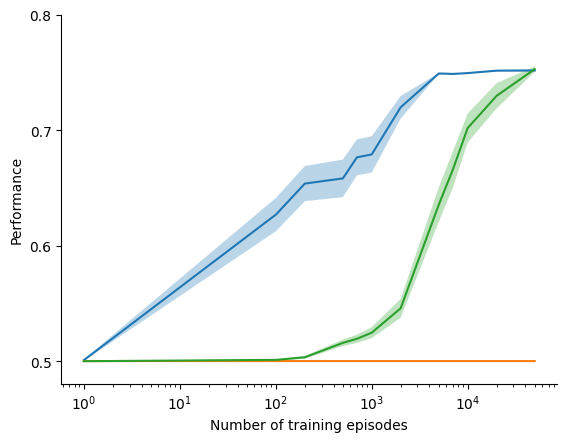

In [6]:
mean_perf = performances_nb_episodes.mean(axis=1)
std_perf = performances_nb_episodes.std(axis=1) / np.sqrt(nb_agents)

plt.plot(nb_episodes_list + 1, mean_perf[:,0], label='stacking modules without fine-tuning')
plt.fill_between(nb_episodes_list + 1, mean_perf[:,0] - std_perf[:,0], mean_perf[:,0] + std_perf[:,0], alpha=0.3)

plt.plot(nb_episodes_list + 1, mean_perf[:,1], label='training from scratch')
plt.fill_between(nb_episodes_list + 1, mean_perf[:,1] - std_perf[:,1], mean_perf[:,1] + std_perf[:,1], alpha=0.3)

plt.plot(nb_episodes_list + 1, mean_perf[:,2], label='training from scratch')
plt.fill_between(nb_episodes_list + 1, mean_perf[:,2] - std_perf[:,2], mean_perf[:,2] + std_perf[:,2], alpha=0.3)

plt.xscale('log')
plt.xlabel('Number of training episodes')
plt.ylabel('Performance')
#plt.legend()
plt.gca().set_yticks([0.5, 0.6, 0.7, 0.8])
plt.gca().set_ylim(0.48, 0.8)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('figures/training_curves_april2026.pdf')

### World model parameters

In [7]:
# performances as a function of the sequence length
nb_agents = 30
nb_simuls = 100
association_probs = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct = np.zeros((nb_agents, nb_simuls, 500))
association_probs_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
ground_truth_probas_reversals = np.zeros((nb_agents, nb_simuls, 500, 4))
chosen_correct_reversals = np.zeros((nb_agents, nb_simuls, 500))
itrial = 300

for idx_agent in range(nb_agents):
    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "WP_GRU_agent{0}".format(idx_agent),
        w_emission=True,
        train_w_emission=True,
        train_in_cat_task_from_scratch=True,
        entropy_reg=2
    )

    self.load_model()

    # generate data
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=None, variable_length=False, tau=0.0)
    initial_probas = self.env.probas.copy()
    env_probas = np.zeros([nb_simuls, 500, 4])
    for i in range(nb_simuls):
        np.random.seed(i)
        env_probas[i] = self.env.probas[i, 0]
        while True:
            if (env_probas[i, 0] != env_probas[i, -1]).any():
                break
            env_probas[i, itrial:] = env_probas[i, 0][np.random.choice(np.arange(4), replace=False, size=4)]

    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=env_probas, variable_length=False)
    result1 = self.evaluate()
    chosen_correct_reversals[idx_agent] = (result1['logpredicts'].argmax(-1) == self.env.correct_weather).float().numpy()

    # psychometric curve
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=initial_probas, variable_length=False, tau=0.0)
    result2 = self.evaluate()
    index_sorted = np.argsort(np.unique(self.env.probas, axis=1).squeeze(), axis=1)
    association_probs[idx_agent] = np.swapaxes(result2['probas_association'][np.arange(nb_simuls)[:, None],: , index_sorted].detach().numpy(), 1, 2)
    chosen_correct[idx_agent] = (result2['logpredicts'].argmax(-1) == self.env.correct_weather).float().numpy()

    # example of a reversal
    env_probas = np.zeros([nb_simuls, 500, 4])
    indexes_sorted = np.zeros([nb_simuls, 4], dtype=int)
    for i in range(nb_simuls):
        np.random.seed(i)
        probas_0 = np.round(self.env.probas[:, 0][i], 1)
        env_probas[i, :itrial] = probas_0
        probas_0_after_reversal = probas_0.copy()
        probas_0_after_reversal[probas_0 == 0.4] = 0.6
        probas_0_after_reversal[probas_0 == 0.6] = 0.8
        probas_0_after_reversal[probas_0 == 0.8] = 0.4
        env_probas[i, itrial:] = probas_0_after_reversal
        indexes_sorted[i] = index_sorted[i]

    self.env.probas = env_probas
    np.random.seed(idx_agent)
    self.env.generate_test_task(num_tasks=nb_simuls, num_trials=500, num_steps=5, probas=self.env.probas, variable_length=False)

    result1 = self.evaluate()
    association_probs_reversals[idx_agent] = np.swapaxes(result1['probas_association'][np.arange(nb_simuls)[:, None], :, indexes_sorted].detach().numpy(), 1, 2)
    ground_truth_probas_reversals[idx_agent] = np.swapaxes(result1['true_association_probas'][np.arange(nb_simuls)[:, None], :, indexes_sorted], 1, 2)

association_probs_reversals = np.mean(association_probs_reversals, axis=1)
ground_truth_probas_reversals = np.mean(ground_truth_probas_reversals, axis=1)
chosen_correct_reversals = np.mean(chosen_correct_reversals, axis=1)

association_probs = np.mean(association_probs, axis=1)
chosen_correct = np.mean(chosen_correct, axis=1)

initialized the emission model
loading model results/source/saved_models/WP_GRU_agent0_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_True_trainInCatTaskFromScratch_True_policyReg_2/model-50000.pth
loaded W_output_association
loaded W_output_emission
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
loaded gru_emission.weight_ih_l0
loaded gru_emission.weight_hh_l0
loaded gru_emission.bias_ih_l0
loaded gru_emission.bias_hh_l0
initialized the emission model
loading model results/source/saved_models/WP_GRU_agent1_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_trainWithEmission_True_trainInCatTaskFromScratch_True_policyReg_2/model-50000.pth
loaded W_output_association
loaded W_output_emission
loaded gru_association.weight_ih_l0
loaded gru_association.weight_hh_l0
loaded gru_association.bias_ih_l0
loaded gru_association.bias_hh_l0
loaded gru_emission.weight_ih_l0
loaded 

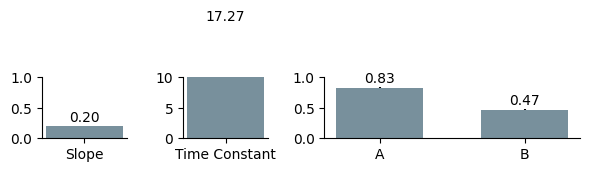

In [8]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# Define the exponential recovery function
def exp_func(t, A, B, tau):
    return A + (B - A) * np.exp(-t / tau)

# Fit reversal parameters (A, B, tau) for each agent
reversal_params = np.zeros((len(chosen_correct_reversals), 3))
reversal_predictions = np.zeros((len(chosen_correct_reversals), 199))
for i, chosen_ in enumerate(chosen_correct_reversals):
    y = chosen_[301:]
    t = np.arange(y.size)
    popt, pcov = curve_fit(exp_func, t, y, p0=[y[-1], y[0], 20])
    reversal_params[i] = popt  # [A, B, tau]
    reversal_predictions[i] = exp_func(t, *popt)
# Fit a slope for the psychometric curve for each agent
from sklearn.linear_model import LinearRegression
slopes = np.zeros(len(association_probs[:, -1]))
intercepts = np.zeros(len(association_probs[:, -1]))
for i, asso in enumerate(association_probs[:, -1]):
    lr = LinearRegression()
    X = np.array([0.2, 0.4, 0.6, 0.8]).reshape(-1, 1)
    y = asso
    lr.fit(X, y)
    slopes[i] = lr.coef_[0]
    intercepts[i] = lr.intercept_

n_agents = len(slopes)

color_all = "#607D8B"
color_A = "#607D8B"
color_B = "#A6A6A6"

# Create a gridspec so that the last subplot is twice as big as the first two
from matplotlib import gridspec
fig = plt.figure(figsize=(6, 4))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 3])
axs = [fig.add_subplot(gs[0, i]) for i in range(3)]

# Plot 1: Slope Bar Plot
ax1 = axs[0]
mean_slope = np.mean(slopes)
sem_slope = np.std(slopes, ddof=1) / np.sqrt(n_agents)
bar1 = ax1.bar([0], [mean_slope], yerr=[sem_slope], color=color_all, capsize=0, alpha=0.85, width=0.7)
ax1.text(0, mean_slope + sem_slope + 0.01, f"{mean_slope:.2f}", ha='center', va='bottom', fontsize=10)
ax1.set_xticks([0])
ax1.set_xticklabels(["Slope"])
ax1.set_ylim([0, 1])
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

# Plot 2: Tau Bar Plot
ax2 = axs[1]
tau_vals = reversal_params[:,2]
mean_tau = np.mean(tau_vals)
sem_tau = np.std(tau_vals, ddof=1) / np.sqrt(n_agents)
bar2 = ax2.bar([0], [mean_tau], yerr=[sem_tau], color=color_all, capsize=0, alpha=0.85, width=0.7)
ax2.text(0, mean_tau + sem_tau + 0.2, f"{mean_tau:.2f}", ha='center', va='bottom', fontsize=10)
ax2.set_xticks([0])
ax2.set_xticklabels(["Time Constant"])
ax2.set_ylim([0, 10])
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Plot 3: Asymptote (A) and Initial (B) on the same plot
ax3 = axs[2]
A_vals = reversal_params[:,0]
B_vals = reversal_params[:,1]
mean_A = np.mean(A_vals)
sem_A = np.std(A_vals, ddof=1) / np.sqrt(n_agents)
mean_B = np.mean(B_vals)
sem_B = np.std(B_vals, ddof=1) / np.sqrt(n_agents)
width = 0.6

ax3.bar([0], [mean_A], yerr=[sem_A], color=color_A, capsize=0, alpha=0.85, width=width, label="Asymptote (A)")
ax3.bar([1], [mean_B], yerr=[sem_B], color=color_A, capsize=0, alpha=0.85, width=width, label="Initial (B)")
ax3.text(0, mean_A + sem_A + 0.02, f"{mean_A:.2f}", ha='center', va='bottom', fontsize=10)
ax3.text(1, mean_B + sem_B + 0.02, f"{mean_B:.2f}", ha='center', va='bottom', fontsize=10)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(["A", "B"])
ax3.set_ylim(0, 1)
ax3.spines['right'].set_visible(False)
ax3.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/WP_from_scratch_april2026_params.pdf')
plt.show()


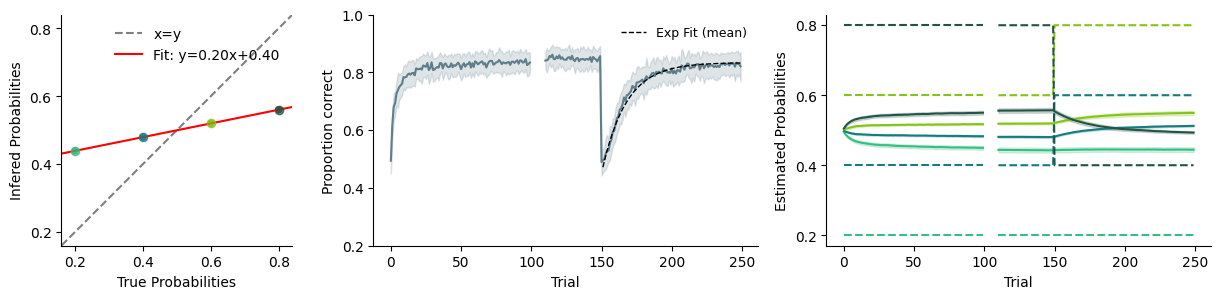

In [9]:
soothing_greens =  ["#34BE82", "#167C80", "#84C318", "#235345"]

slope = slopes.mean()
intercept = intercepts.mean()
fig, axs = plt.subplots(1, 3, figsize=(15, 3), gridspec_kw={'width_ratios': [2, 3, 3]})
pmeans = association_probs[:, -1].mean(axis=0)
pstds = association_probs[:, -1].std(axis=0)
true_probs = np.array([0.2, 0.4, 0.6, 0.8])

axs[0].scatter(true_probs, pmeans, alpha=0.7, color=soothing_greens, s=20)
for i, color in enumerate(soothing_greens):
    axs[0].errorbar(true_probs[i], pmeans[i], yerr=pstds[i], alpha=0.7, color=color, fmt='o')

# Plot the reference x=y line
axs[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='x=y')

# Plot the best-fit linear curve: y = slope * x + intercept
x_lin = np.linspace(0, 1, 100)
y_lin = slope * x_lin + intercept
axs[0].plot(x_lin, y_lin, color="red", linestyle="-", linewidth=1.5, label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
axs[0].legend(frameon=False)

axs[0].set_ylabel('Infered Probabilities')
axs[0].set_xlabel('True Probabilities')
axs[0].set_xlim(0.16, 0.84)
axs[0].set_xticks([0.2, 0.4, 0.6, 0.8])
axs[0].set_ylim(0.16, 0.84)
axs[0].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[0].set_aspect('equal', adjustable='box')
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)

# reversal plots of beliefs
mean_correct = chosen_correct.mean(axis=0)
std_correct = chosen_correct.std(axis=0)
mean_correct_reversals = chosen_correct_reversals.mean(axis=0)
std_correct_reversals = chosen_correct_reversals.std(axis=0)
xx = np.arange(110, 250)
pmean_correct = mean_correct[:100]
pstd = std_correct[:100]
light_grey = "#607D8B"
axs[1].plot(pmean_correct, color=light_grey)
axs[1].fill_between(np.arange(100), pmean_correct - pstd, pmean_correct + pstd, alpha=0.2, color=light_grey)
axs[1].set_ylabel('Proportion correct')
axs[1].set_xlabel('Trial')
axs[1].plot(xx, mean_correct_reversals[260:400], color=light_grey)
axs[1].fill_between(xx, mean_correct_reversals[260:400] - std_correct_reversals[260:400], mean_correct_reversals[260:400] + std_correct_reversals[260:400], alpha=0.2, color=light_grey)
axs[1].set_xticks([0, 50, 100, 150, 200, 250])
axs[1].set_ylim(0.2, 1.)
axs[1].set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)

# Plot mean fitted exponential after reversal for the black mean
# Use exp_func(t, A, B, tau) and mean_B, mean_A, mean_tau from previous fit
if 'mean_A' in locals() and 'mean_B' in locals() and 'mean_tau' in locals():
    t_fit = np.arange(151, 250)
    exp_curve = exp_func(t_fit - 151, mean_A, mean_B, mean_tau)
    axs[1].plot(t_fit, exp_curve[:len(t_fit)], "--", color='black', linewidth=1, label='Exp Fit (mean)')
    axs[1].legend(frameon=False, fontsize=9, loc='upper right')

# reversal plots of beliefs
mean_association_probs_reversals = association_probs_reversals.mean(axis=0)
std_association_probs_reversals = association_probs_reversals.std(axis=0)
mean_ground_truth_probas_reversals = ground_truth_probas_reversals.mean(axis=0)
xx = np.arange(110, 250)
for i in range(4):
    pmean = association_probs.mean(axis=0)[:100, i]
    pstd = association_probs.std(axis=0)[:100, i]
    axs[2].plot(pmean, color=soothing_greens[i])
    axs[2].fill_between(np.arange(100), pmean - pstd, pmean + pstd, alpha=0.2, color=soothing_greens[i])
    p = np.array([0.2, 0.4, 0.6, 0.8])[i]
    axs[2].plot(p * np.ones(100), linestyle='--', color=soothing_greens[i])
axs[2].set_ylabel('Estimated Probabilities')
axs[2].set_xlabel('Trial')
for i in range(4):
    axs[2].plot(xx, mean_association_probs_reversals[260:400, i], color=soothing_greens[i])
    axs[2].plot(xx, mean_ground_truth_probas_reversals[260:400, i], linestyle='--', color=soothing_greens[i])
    axs[2].fill_between(xx, 
                        mean_association_probs_reversals[260:400, i] - std_association_probs_reversals[260:400, i], 
                        mean_association_probs_reversals[260:400, i] + std_association_probs_reversals[260:400, i], 
                        alpha=0.2, color=soothing_greens[i])
    axs[2].set_xticks([0, 50, 100, 150, 200, 250])
axs[2].set_ylim(0.17, 0.83)
axs[2].set_yticks([0.2, 0.4, 0.6, 0.8])
axs[2].spines['right'].set_visible(False)
axs[2].spines['top'].set_visible(False)
plt.savefig('figures/WP_reversal_from_scratch_april_2026.pdf')

plt.show()

In [10]:
pwd

'/Users/csmfindling/Documents/Postdoc-Geneva/neuralHMMs/code/WP'